In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch  
from torch import nn

In [2]:
x = t.rand(3,4)
x

tensor([[0.8200, 0.3795, 0.9061, 0.5663],
        [0.8526, 0.7814, 0.6466, 0.9656],
        [0.1864, 0.2016, 0.5805, 0.9781]])

In [10]:
y = t.tensor([1,2,3])
y+10

tensor([11, 12, 13])

In [4]:
x.T

tensor([[0.8200, 0.8526, 0.1864],
        [0.3795, 0.7814, 0.2016],
        [0.9061, 0.6466, 0.5805],
        [0.5663, 0.9656, 0.9781]])

In [6]:
t.__version__

'2.11.0+cpu'

In [8]:
w = 0.7
b = 0.3
start = 0
stop  = 1
step = 0.02
X = t.arange(start,stop,step).unsqueeze(dim=1)
y = w * X + b

In [10]:
X.shape

torch.Size([50, 1])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

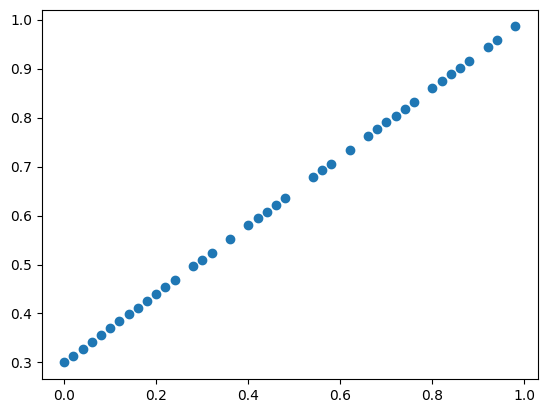

In [16]:
plt.scatter(X_train,y_train)

In [19]:
param = nn.Parameter(t.randn(3,3))
param

Parameter containing:
tensor([[ 1.8026, -0.8022,  1.0526],
        [ 2.3002,  0.8798, -0.8225],
        [-0.6899, -0.9075,  0.1651]], requires_grad=True)

In [ ]:
import torch
torch.manual_seed(42)
 
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # initialize weight and bias
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        # y = wx + b
        return self.weight * x + self.bias

In [112]:
torch.manual_seed(42)
model = LinearRegressionModel()
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [114]:
y_pred = model(X_test)
y_pred

tensor([[0.2163],
        [0.3914],
        [0.3308],
        [0.4318],
        [0.2433],
        [0.4520],
        [0.3039],
        [0.2972],
        [0.3443],
        [0.2568]], grad_fn=<AddBackward0>)

In [ ]:
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

# reproducibility
torch.manual_seed(42)

# -----------------------------
# Model definition
# -----------------------------
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.weight * x + self.bias


# -----------------------------
# Create data (y = 2x + 1)
# -----------------------------
X1 = torch.arange(0, 10).float()
X2 = X1 ** 2  # second feature (example)

X = torch.stack((X1, X2), dim=1).to(device)

y = 0.5 * X1 + 0.25 * X2 + 10
y = y.unsqueeze(1).to(device)


# -----------------------------
# Initialize model
# -----------------------------
model = LinearRegressionModelV2().to(device)



# -----------------------------
# Before training
# -----------------------------
print("Before training:")
for name, param in model.named_parameters():
    print(name, param )


# -----------------------------
# Loss and optimizer
# -----------------------------
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


# -----------------------------
# Training loop
# -----------------------------
epochs = 10000
losses = []
for epoch in range(epochs):
    
    # Forward pass
    y_pred = model(X)
    
    # Compute loss
    loss = loss_fn(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # Update parameters
    optimizer.step()
    losses.append(loss.item())
        
    if loss.item() < 1e-6:
        print(f"Stopped early at epoch {epoch}")
        break


    if epoch % 50 == 0:
        losses.append(loss.item())
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


    # if epoch % 20 == 0:
    #     print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# -----------------------------
# After training
# -----------------------------
print("\nAfter training:")
for name, param in model.named_parameters():
    print(name, param )


# -----------------------------
# Test prediction
# -----------------------------
print("\nPredictions:")
print(model(X[:5]))

# Plot
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()


NameError: name 'LinearRegressionModelV2' is not defined

In [14]:
torch.save(model.state_dict(),'linear_regression.pth')

In [18]:
model_loaded = LinearRegressionModel()
model_loaded.load_state_dict(torch.load('linear_regression.pth'))
model_loaded.eval()

LinearRegressionModel()

In [21]:
print(f"Loaded {model_loaded(X[:3])}")
print(f"original {model(X[:3])}")

Loaded tensor([[0.6646],
        [2.7181],
        [4.7716]], grad_fn=<AddBackward0>)
original tensor([[0.6646],
        [2.7181],
        [4.7716]], grad_fn=<AddBackward0>)


In [25]:
for k,v in model.state_dict().items():
    print(k,v)

weight tensor([2.0535])
bias tensor([0.6646])


In [6]:
print(torch.cuda.is_available())

True


In [ ]:
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

# reproducibility
torch.manual_seed(42)

# -----------------------------
# Model definition
# -----------------------------
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(2,1)
        
       

    def forward(self, x):
        return self.linear_layer(x)


# -----------------------------
# Create data (y = 2x + 1)
# -----------------------------

X1 = torch.arange(0, 10).float()
X2 = X1 ** 2  # second feature (example)

X = torch.stack((X1, X2), dim=1).to(device)

y = 0.5 * X1 + 0.25 * X2 + 10
y = y.unsqueeze(1).to(device)

# -----------------------------
# Initialize model
# -----------------------------
model = LinearRegressionModelV2().to(device)
 


# -----------------------------
# Before training
# -----------------------------
print("Before training:")
for name, param in model.named_parameters():
    print(name, param )


# -----------------------------
# Loss and optimizer
# -----------------------------
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


# -----------------------------
# Training loop
# -----------------------------
epochs = 100000
losses = []
for epoch in range(epochs):
    
    # Forward pass
    y_pred = model(X)
    
    # Compute loss
    loss = loss_fn(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # Update parameters
    optimizer.step()
    losses.append(loss .item())
    
    if loss.item() < 1e-6:
        print(f"Stopped early at epoch {epoch}")
        break


    if epoch % 50 == 0:
        losses.append(loss.item())
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# -----------------------------
# After training
# -----------------------------
print("\nAfter training:")
for name, param in model.named_parameters():
    print(name, param )


# -----------------------------
# Test prediction
# -----------------------------
print("\nPredictions:")
print(model(X[:5]))

# Plot
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()


Before training:
linear_layer.weight Parameter containing:
tensor([[0.5406, 0.5869]], device='cuda:0', requires_grad=True)
linear_layer.bias Parameter containing:
tensor([-0.1657], device='cuda:0', requires_grad=True)
Epoch 0, Loss: 84.032997
Epoch 50, Loss: 16269187497594163952864150924820480.000000
Epoch 100, Loss: inf
Epoch 150, Loss: nan
Epoch 200, Loss: nan
Epoch 250, Loss: nan
Epoch 300, Loss: nan
Epoch 350, Loss: nan
Epoch 400, Loss: nan
Epoch 450, Loss: nan
Epoch 500, Loss: nan
Epoch 550, Loss: nan
Epoch 600, Loss: nan
Epoch 650, Loss: nan
Epoch 700, Loss: nan
Epoch 750, Loss: nan
Epoch 800, Loss: nan
Epoch 850, Loss: nan
Epoch 900, Loss: nan
Epoch 950, Loss: nan
Epoch 1000, Loss: nan
Epoch 1050, Loss: nan
Epoch 1100, Loss: nan
Epoch 1150, Loss: nan
Epoch 1200, Loss: nan
Epoch 1250, Loss: nan
Epoch 1300, Loss: nan
Epoch 1350, Loss: nan
Epoch 1400, Loss: nan
Epoch 1450, Loss: nan
Epoch 1500, Loss: nan
Epoch 1550, Loss: nan
Epoch 1600, Loss: nan
Epoch 1650, Loss: nan
Epoch 1700, 

KeyboardInterrupt: 

In [11]:
n = 12